Tento spisek lze chápat jako přirozené pokračování notebook langchain_2026 se vším, co k tomu patří. Tudíž i včetně upozornění, že se jedná o moje osobní poznámky k danému tématu, tj. není to žádný ucelený text, který by mohl někomu sloužit jako učební text. 

In [1]:
import os
import operator
from typing import Literal
from typing_extensions import TypedDict, Annotated

from IPython.display import Image, display
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.messages import AnyMessage, SystemMessage, ToolMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

load_dotenv()

c:\primary\programovani\workshops\environment\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Jednoduchý příklad použití
Začněme nejprve tutoriálových příkladem, který lze nalézt na stránkách Langgraphu.  
Nejprve si vyrobíme objekt reprezentující model.

In [2]:
llm_model = init_chat_model(
    model="gpt-4.1-mini",
    model_provider="openai",
    api_key=os.getenv("OPENAI_API_KEY")
)

Následně si vyrobíme tooly (funkce s dekorátorem tool). Všimněme si, že si tu vytváříme mapování jména funkce na funkci samotné alias "tools_by_name". K tomu se vrátíme za chvíli při diskusi buňky obsahující funkci *tool_node*.

In [3]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b


tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = llm_model.bind_tools(tools)

Zatím jsme nedělali nic, co bychom neznali už z Langchainu - to se nyní změní.  
Na první pohled to vypadá, že si vytváříme třídu MessagesState, která dědí od TypedDict. Ono je to ale trochu složítější - TypedDict pochází od typing_extensions a tak přináší jen možnost objekty kontrolovat skrz utility typu mypy (anebo třeba Langchain, který se podle toho dokáže nějak zařídit). Konkrétně tady říkáme, že slovník typu MessagesState bude obsahovat jen dva klíče - "messages" a "llm_calls". "llm_calls" má být vždy jen integer. U "messages" se vyskytuje jakási věc zvaná *Annotated*. Ta dovoluje k určitému datovému typu připojit určitá metadata. V našem případě k listu zpráv bylo připojeno "operator.add". Tento operátor bude Langchain interpretovat tak, že až bude seznam zpráv aktualizovat, nepřepíše staré zprávy novými, ale appenduje je.  
Jak už padlo, Langchain podle tohoto bude dělat nějaké dodatečné operace. Mypy by řvala jen pokud by odpovídající slovník neměl pole "messages" a "llm_calls" (klidně může mít polí víc, to už mypy nezajímá) o odpovídajících datových typech.

In [7]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

Nyní si vytvoříme funkci, které instanci MessagesState vezme, něco s ní udělá a znova ji vrátí. To "něco s ní udělá" zde konrkétně znamená, že dojde k provolání jazykového modelu (a výstup se vloží do "messages" a že se inkrementuje "llm_calls".

In [4]:
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [
                    SystemMessage(
                        content="You are a helpful assistant tasked with performing arithmetic on a set of inputs."
                    )
                ]
                + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

Nyní si vydefinujeme funkci *tool_node*. Pro její pochopení je třeba vědět, že věci, skrz které v ní ve for loopu iterujeme, mají podobu
```python
{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_nJneCcC2iYFHlaRsY0Ax1Uex', 'type': 'tool_call'}
```
Tj. máme tu jméno toolu/funkce v podobě stringu, avšak nikoli funkci jako takovou. Právě k tomu potřebujeme slovník *tools_by_name*, který mapuje jméno na funkci samotnou. Na té potom provoláme metodu *invoke*, přičemž ji podhodíme parametry z LLMka (tool_call\["args"\], zde půjde o {'a': 3, 'b': 4}). Výsledek - zde sečtení dvou čísel alias 7, se vloží do proměnné "observation" a následně do *ToolMessage*.  
Pozn.: v lanchchain_2026 jsme to takto nedělali, neboť tam jsme funkci provolávali natvrdo jejím do kódu zahardcodovaným jménem. Takovýto potup byl fajn pro ukázku, ale v praxi by to pochopitelně použitelné nebylo.

In [15]:
from langchain.messages import ToolMessage

def tool_node(state: dict):
    """Performs the tool call"""
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

Nyní si vytvořme další funkci. Ta se podívá do proměnné *state*. Pokud poslední zpráva v ní obsahuje zadání na provolání toolu, tak se vrátí string "tool_node", jinak se vrátí langchainé objekt *END*.

In [16]:
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tool_node"

    return END

Nyní je třeba to celé dát dohromady.  
Nejprve si skrz
```python
agent_builder = StateGraph(MessagesState)
```
vytvoříme objekt reprezentující graf alias posloupnost kroků, které se mají udělat. Do něj vložíme třídu (nikoli instanci!) stavu grafu - ta říká, co za atributy na sebe má vlastně graf navázat (obvykle zde bude historie konverzace).  
Máme tedy graf, ten je ale v současnosti prázdný. Musíme mu tudíž vytvořit nody (s pomocí metody *add_node*). Jedná se o funkce, která se spustí, když se k nim (resp. k jejich nodu) při průchodu grafem dostaneme. Berou jako svůj vstup slovník a slovník i vracejí - a ten slovník obsahuje právě stav grafu.  
Nody samy o sobě nejsou k ničemu, když nejsou spojeny hranami (edge). Na prosté spojení slouží metoda *add_edge* - první parametr je počáteční node, druhý parametr koncový node. Pokud ale musí cestu grafu určovat dynamicky nějaká logika, sáhneme po *add_conditional_edges*. Ta jako první parametr přebírá startovní node, v druhém parametru je ale funkce (nikoli nodová), která by měla vrátit jeden z nodů zmíněných v listu, kterým je třetí parametr.  
Na závěr je třeba graf zkompilovat (s pomocí metody *compile*) - na nezkompilovaném by neběžela *invoke* metoda.


In [20]:
agent_builder = StateGraph(MessagesState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

agent = agent_builder.compile()

In [22]:
help(agent.get_graph)

Help on method get_graph in module langgraph.pregel.main:

get_graph(config: 'RunnableConfig | None' = None, *, xray: 'int | bool' = False) -> 'Graph' method of langgraph.graph.state.CompiledStateGraph instance
    Return a drawable representation of the computation graph.



Pokud si chceme zkompilovaný graf prohlédnout, musíme ho napřed dostat do "grafové" podoby s pomocí metody *get_graph*. Parametr *xray* říká, zda se mají do výsledku dostat i subgrafy. Takovýto graf má metody *draw_mermaid_png*, díky které ho už můžeme vidět v lidsky srozumitelné formě.  
Samotné provolání grafu už je obyčejné *invoke*, do kterého se vloží slovník s "messages" klíčem.

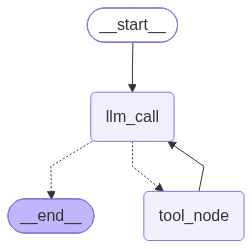

We are in 'tool_node' function
call:
{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_nJneCcC2iYFHlaRsY0Ax1Uex', 'type': 'tool_call'}
tool:  name='add' description='Adds `a` and `b`.\n\n    Args:\n        a: First int\n        b: Second int' args_schema=<class 'langchain_core.utils.pydantic.add'> func=<function add at 0x000002A940B47CE0> 
tool name:  add 
observation:  7
================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_nJneCcC2iYFHlaRsY0Ax1Uex)
 Call ID: call_nJneCcC2iYFHlaRsY0Ax1Uex
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3 added to 4 equals 7.


In [18]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

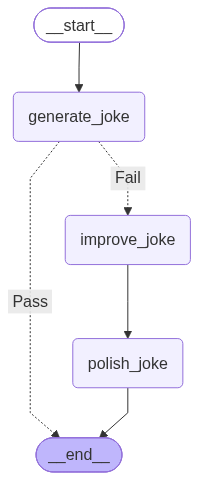

Initial joke:
Why did the calendar bring a ladder to work?  
Because it wanted to reach a higher day!

--- --- ---

Final joke:
Why did the calendar bring a ladder to work?  
Because it wanted to reach a higher day!


In [29]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

llm = init_chat_model(
    model="gpt-4.1-mini",
    model_provider="openai",
    api_key=os.getenv("OPENAI_API_KEY")
)

# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "day"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])